# Idea

This notebook aggregates the data on MSISDN but also temporally. It splits the raw CDR rows into chunks each covering a day of activity, then computes features based on those chunks. Each daily behavior form a new data entity for the model. The MSISDN will not be part of the features, but only an index to verify the label data. This prevents data leakage by shifting the model from recognizing specific MSISDNs in the training dataset to only focusing on behavior.

<b>This notebook generates a clean, unsplit, profiled dataset.</B>

---

### Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

### Paths

In [2]:
PROJECT_ROOT = Path.cwd().parent.parent

DATA_PATH = PROJECT_ROOT / "data"

PROFILE_PATH = DATA_PATH / "profiles_new_feat"

CDR_PATH = DATA_PATH / "raw_cdr" / "clean_cdr.parquet"

FLAGGED_CELL_PATH = DATA_PATH/ "flagged_cells.npy"

### Load data

In [3]:
cdr_df = pd.read_parquet(CDR_PATH)

print("CDR shape:", cdr_df.shape)

CDR shape: (7213036, 9)


---
### Feature extraction function

In [4]:
def extract_features(day_df):

    import numpy as np
    import pandas as pd

    POS_INF_SENTINEL = 999999
    NEG_INF_SENTINEL = 0.0

    # ==================================================
    # Load flagged cells
    # ==================================================

    flagged_cells = set(
        np.load(FLAGGED_CELL_PATH)
    )

    # ==================================================
    # Helpers
    # ==================================================

    def safe_divide(num, den):

        result = num / den

        result = result.replace(
            np.inf,
            POS_INF_SENTINEL
        )

        result = result.replace(
            -np.inf,
            NEG_INF_SENTINEL
        )

        result = result.fillna(0)

        return result


    # ==================================================
    # Preparation
    # ==================================================

    day_df = day_df.copy()

    day_df["answer_hour"] = (
        day_df["answer_time"]
        .dt.hour
    )

    day_df["is_outgoing"] = (
        day_df["record_type"] == 0
    )

    day_df["is_incoming"] = (
        day_df["record_type"] == 1
    )

    day_df["is_flagged"] = (
        day_df["cell"].isin(flagged_cells)
    )

    # Time categories
    day_df["category_day"] = 0

    day_df.loc[
        (day_df.answer_hour >= 0) &
        (day_df.answer_hour <= 5),
        "category_day"
    ] = 1

    day_df.loc[
        (day_df.answer_hour >= 6) &
        (day_df.answer_hour <= 11),
        "category_day"
    ] = 2

    day_df.loc[
        (day_df.answer_hour >= 12) &
        (day_df.answer_hour <= 17),
        "category_day"
    ] = 3

    day_df.loc[
        (day_df.answer_hour >= 18) &
        (day_df.answer_hour <= 23),
        "category_day"
    ] = 4


    grouped = day_df.groupby("msisdn")

    features = pd.DataFrame(
        index=grouped.size().index
    )


    # ==================================================
    # Label
    # ==================================================

    features["label"] = grouped["label"].agg(
        lambda x: x.mode().iloc[0]
    )


    # ==================================================
    # Basic activity
    # ==================================================

    features["nb_out_calls"] = grouped["is_outgoing"].sum()

    features["nb_in_calls"] = grouped["is_incoming"].sum()


    # ==================================================
    # Distinct contacts
    # ==================================================

    features["nb_called_numbers"] = grouped.apply(
        lambda x: x.loc[
            x.is_outgoing,
            "called_number"
        ].nunique()
    )


    # ==================================================
    # Duration features
    # ==================================================

    features["avg_out_duration"] = grouped.apply(
        lambda x: x.loc[
            x.is_outgoing,
            "duration_in_seconds"
        ].mean()
    )

    features["avg_in_duration"] = grouped.apply(
        lambda x: x.loc[
            x.is_incoming,
            "duration_in_seconds"
        ].mean()
    )


    # ==================================================
    # Ratios
    # ==================================================

    features["ratio_in_vs_out"] = safe_divide(
        features["nb_in_calls"],
        features["nb_out_calls"]
    )


    features["ratio_distinct_vs_out"] = safe_divide(
        features["nb_called_numbers"],
        features["nb_out_calls"]
    )


    features["ratio_in_duration_vs_out_duration"] = safe_divide(
        features["avg_in_duration"],
        features["avg_out_duration"]
    )


    # ==================================================
    # Time of day features
    # ==================================================

    features["dawn_count"] = grouped.apply(
        lambda x: (
            x.category_day == 1
        ).sum()
    )

    features["day_count"] = grouped.apply(
        lambda x: (
            x.category_day == 2
        ).sum()
    )

    features["afternoon_count"] = grouped.apply(
        lambda x: (
            x.category_day == 3
        ).sum()
    )

    features["night_count"] = grouped.apply(
        lambda x: (
            x.category_day == 4
        ).sum()
    )


    features["ratio_dawn_vs_out"] = safe_divide(
        features["dawn_count"],
        features["nb_out_calls"]
    )

    features["ratio_day_vs_out"] = safe_divide(
        features["day_count"],
        features["nb_out_calls"]
    )

    features["ratio_afternoon_vs_out"] = safe_divide(
        features["afternoon_count"],
        features["nb_out_calls"]
    )

    features["ratio_night_vs_out"] = safe_divide(
        features["night_count"],
        features["nb_out_calls"]
    )


    # ==================================================
    # Fraud indicators
    # ==================================================

    features["nb_flagged_calls"] = grouped["is_flagged"].sum()

    features["ratio_flagged_vs_out"] = safe_divide(
        features["nb_flagged_calls"],
        features["nb_out_calls"]
    )


    # ==================================================
    # Mobility features
    # ==================================================

    features["nb_distinct_lacs"] = grouped["lac"].nunique()

    features["ratio_distinct_lacs_vs_out"] = safe_divide(
        features["nb_distinct_lacs"],
        features["nb_out_calls"]
    )


    features["nb_distinct_cell_ids"] = grouped["cell"].nunique()

    features["ratio_distinct_cell_ids_vs_out"] = safe_divide(
        features["nb_distinct_cell_ids"],
        features["nb_out_calls"]
    )


    # ==================================================
    # Average delay between outgoing calls
    # ==================================================

    def calculate_avg_out_delay(x):

        outgoing_times = (
            x.loc[
                x.is_outgoing,
                "answer_time"
            ]
            .sort_values()
        )

        if len(outgoing_times) < 2:
            return 0

        delays = (
            outgoing_times
            .diff()
            .dt.total_seconds()
            .dropna()
        )

        if len(delays) == 0:
            return 0

        return delays.mean()


    features["avg_delay_per_day"] = grouped.apply(
        calculate_avg_out_delay
    )


    # ==================================================
    # Cleanup
    # ==================================================

    features = features.replace(
        [np.inf, -np.inf],
        [POS_INF_SENTINEL, NEG_INF_SENTINEL]
    )

    features = features.fillna(0)

    return features.reset_index()

### Daily profiling function

In [5]:
def build_daily_profiles(df):

    df = df.copy()

    df["profile_date"] = df["answer_time"].dt.date

    daily_profiles = []

    unique_days = sorted(
        df["profile_date"].unique()
    )

    print(f"Processing {len(unique_days)} days...")

    for i, day in enumerate(unique_days, start=1):

        day_df = df[
            df["profile_date"] == day
        ].copy()

        profile = extract_features(day_df)

        profile["profile_date"] = day

        # ====================================
        # Save daily profile
        # ====================================

        file_name = f"day_{i:02d}.parquet"

        profile.to_parquet(
            f"{PROFILE_PATH}/{file_name}",
            index=False
        )

        print(f"Saved {file_name}")

        daily_profiles.append(profile)

    result = pd.concat(
        daily_profiles,
        ignore_index=True
    )

    return result

---
### Build profiles

In [6]:
profiles = build_daily_profiles(cdr_df)

print(profiles.shape)

profiles.head()

Processing 15 days...


C:\Users\ali.farhat\AppData\Local\Temp\ipykernel_15100\94192098.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features["nb_called_numbers"] = grouped.apply(
C:\Users\ali.farhat\AppData\Local\Temp\ipykernel_15100\94192098.py:132: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features["avg_out_duration"] = grouped.apply(
C:\Users\ali.farhat\AppData\Local\Temp\ipykernel_15100\94192098.py:139: FutureWarning: Data

Saved day_01.parquet


C:\Users\ali.farhat\AppData\Local\Temp\ipykernel_15100\94192098.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features["nb_called_numbers"] = grouped.apply(
C:\Users\ali.farhat\AppData\Local\Temp\ipykernel_15100\94192098.py:132: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features["avg_out_duration"] = grouped.apply(
C:\Users\ali.farhat\AppData\Local\Temp\ipykernel_15100\94192098.py:139: FutureWarning: Data

Saved day_02.parquet


...

C:\Users\ali.farhat\AppData\Local\Temp\ipykernel_15100\94192098.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features["nb_called_numbers"] = grouped.apply(
C:\Users\ali.farhat\AppData\Local\Temp\ipykernel_15100\94192098.py:132: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features["avg_out_duration"] = grouped.apply(
C:\Users\ali.farhat\AppData\Local\Temp\ipykernel_15100\94192098.py:139: FutureWarning: Data

Saved day_14.parquet


C:\Users\ali.farhat\AppData\Local\Temp\ipykernel_15100\94192098.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features["nb_called_numbers"] = grouped.apply(
C:\Users\ali.farhat\AppData\Local\Temp\ipykernel_15100\94192098.py:132: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features["avg_out_duration"] = grouped.apply(
C:\Users\ali.farhat\AppData\Local\Temp\ipykernel_15100\94192098.py:139: FutureWarning: Data

Saved day_15.parquet
(428800, 26)


,msisdn,label,nb_out_calls,nb_in_calls,nb_called_numbers,avg_out_duration,avg_in_duration,ratio_in_vs_out,ratio_distinct_vs_out,ratio_in_duration_vs_out_duration,...,ratio_afternoon_vs_out,ratio_night_vs_out,nb_flagged_calls,ratio_flagged_vs_out,nb_distinct_lacs,ratio_distinct_lacs_vs_out,nb_distinct_cell_ids,ratio_distinct_cell_ids_vs_out,avg_delay_per_day,profile_date
0,22362444330,0,0,5,0,0.0,136.200000,999999.0,0.0,0.000000,...,999999.0,999999.0,5,999999.0,1,999999.0,2,999999.0,0.0,2022-11-01
1,22667898029,0,0,1,0,0.0,90.000000,999999.0,0.0,0.000000,...,999999.0,0.0,1,999999.0,1,999999.0,1,999999.0,0.0,2022-11-01
2,22995468560,0,0,2,0,0.0,38.000000,999999.0,0.0,0.000000,...,999999.0,0.0,2,999999.0,1,999999.0,2,999999.0,0.0,2022-11-01
3,2250101000087,0,2,3,2,57.5,23.666667,1.5,1.0,0.411594,...,1.5,1.0,5,2.5,2,1.0,4,2.0,885.0,2022-11-01
4,2250101000108,0,10,2,9,329.1,40.000000,0.2,0.9,0.121544,...,0.7,0.0,12,1.2,1,0.1,5,0.5,3422.0,2022-11-01


### Verification

In [7]:
print("Profiles")
display(profiles.describe())

Profiles


,msisdn,label,nb_out_calls,nb_in_calls,nb_called_numbers,avg_out_duration,avg_in_duration,ratio_in_vs_out,ratio_distinct_vs_out,ratio_in_duration_vs_out_duration,...,ratio_day_vs_out,ratio_afternoon_vs_out,ratio_night_vs_out,nb_flagged_calls,ratio_flagged_vs_out,nb_distinct_lacs,ratio_distinct_lacs_vs_out,nb_distinct_cell_ids,ratio_distinct_cell_ids_vs_out,avg_delay_per_day
count,4.288000e+05,428800.000000,428800.000000,428800.000000,428800.000000,428800.000000,428800.000000,428800.000000,428800.000000,428800.000000,...,428800.000000,428800.000000,428800.000000,428800.000000,428800.000000,428800.000000,428800.000000,428800.000000,428800.000000,428800.000000
mean,2.250062e+12,0.057500,9.663883,7.157563,5.657943,102.221894,103.048439,154326.751622,0.579516,3.756247,...,88895.055163,91287.801661,95030.790723,14.588216,134264.397722,1.699130,154326.141746,5.993811,154326.614835,4273.997534
std,1.317441e+10,0.232796,10.581301,8.455478,5.965187,146.050116,151.382675,361260.675363,0.323986,1527.149090,...,284591.408537,288017.120295,293256.673373,15.676653,340934.207374,1.350052,361260.935891,5.879984,361260.733795,5675.392924
min,2.236244e+10,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.005714,1.000000,0.009091,0.000000
25%,2.250104e+12,0.000000,2.000000,2.000000,2.000000,34.916667,37.750000,0.352941,0.400000,0.119298,...,0.200000,0.250000,0.200000,4.000000,1.142857,1.000000,0.111111,2.000000,0.434783,710.593750
50%,2.250143e+12,0.000000,7.000000,5.000000,4.000000,67.000000,63.500000,0.758621,0.615385,0.643726,...,0.500000,0.567568,0.500000,10.000000,1.555556,1.000000,0.250000,4.000000,0.800000,2866.000000
75%,2.250154e+12,0.000000,14.000000,10.000000,8.000000,119.363636,112.430804,2.000000,0.833333,1.247371,...,1.000000,1.000000,1.000000,20.000000,2.500000,2.000000,0.714286,8.000000,1.545455,5386.262500
max,2.252123e+12,1.000000,218.000000,959.000000,212.000000,6129.000000,7373.000000,999999.000000,1.000000,999999.000000,...,999999.000000,999999.000000,999999.000000,959.000000,999999.000000,23.000000,999999.000000,109.000000,999999.000000,84315.000000


---
### Save outputs

In [8]:
ALL_PROFILE_PATH = (
    PROFILE_PATH /
    "all_profiles.parquet"
)

profiles.to_parquet(
    ALL_PROFILE_PATH,
    index=False
)

print("Saved:")
print(ALL_PROFILE_PATH)

Saved:
c:\Users\ali.farhat\Documents\simbox-project\data\profiles_new_feat\all_profiles.parquet


---
## EXTRA: Behavior change visualization

This cell takes a sample of 10 fraudulent msisdns and plots the normalized values of the features across days. This shows how the behavior of a fraudulent msisdn changes over time.

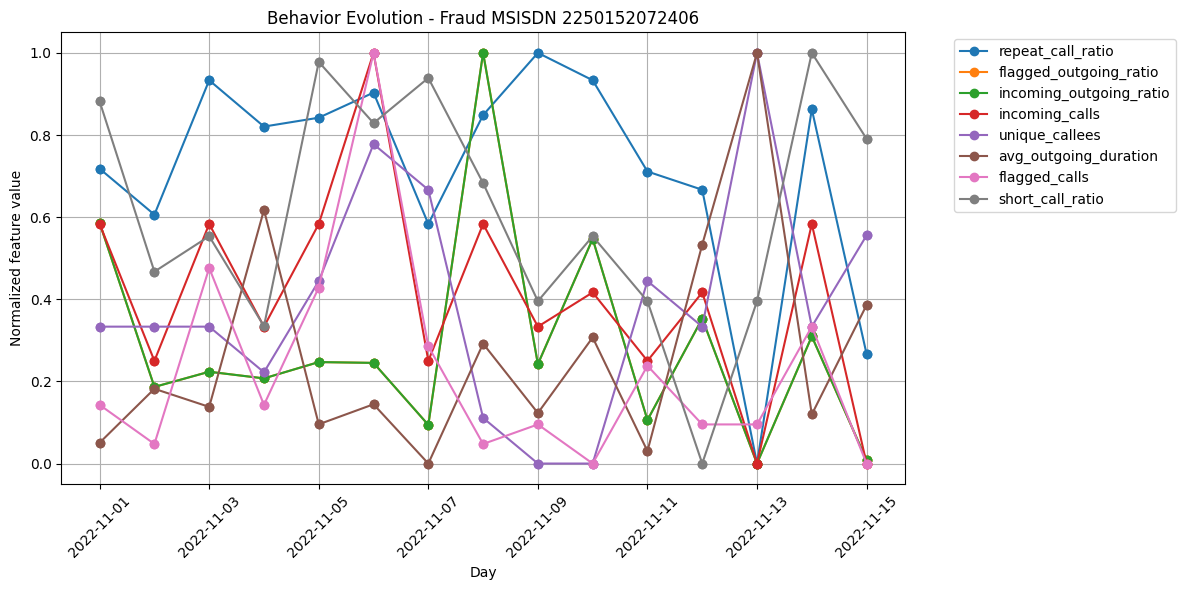

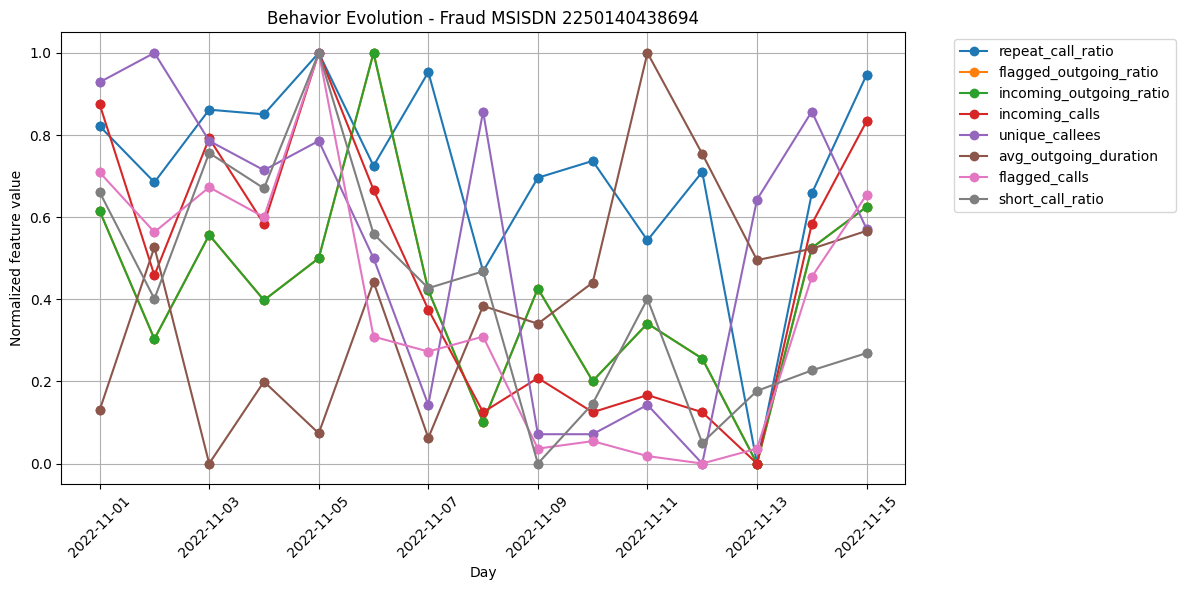

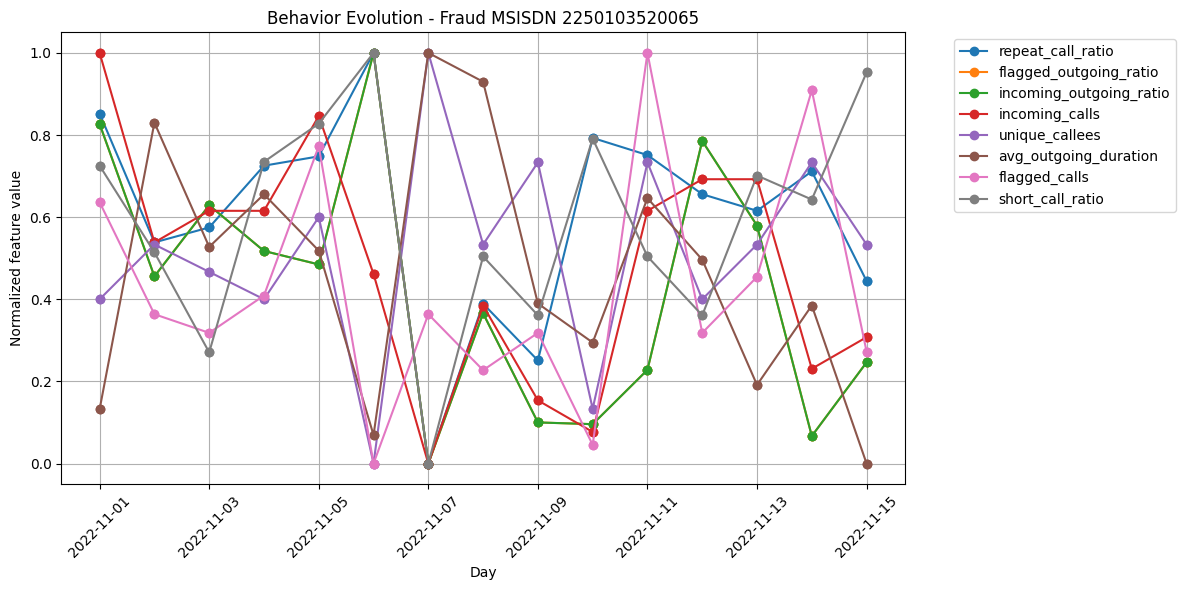

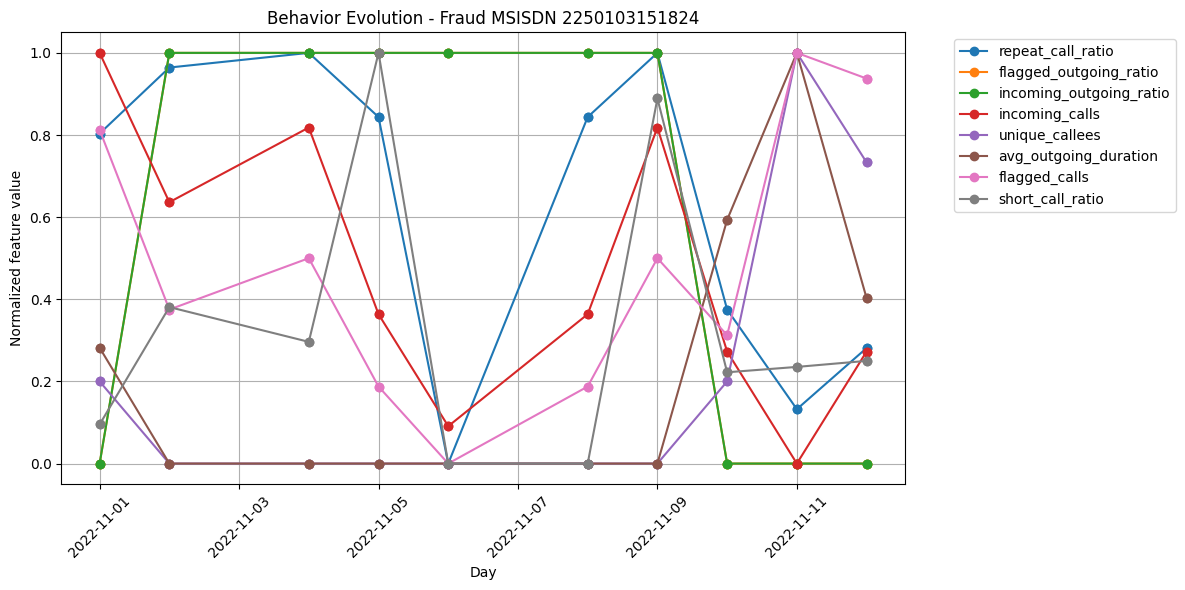

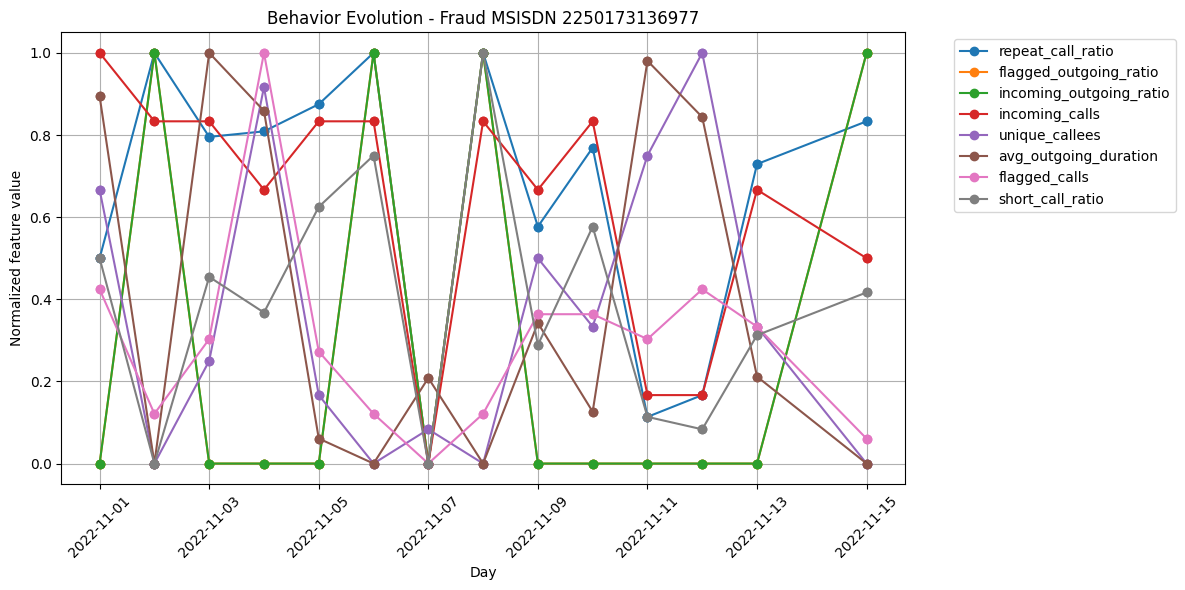

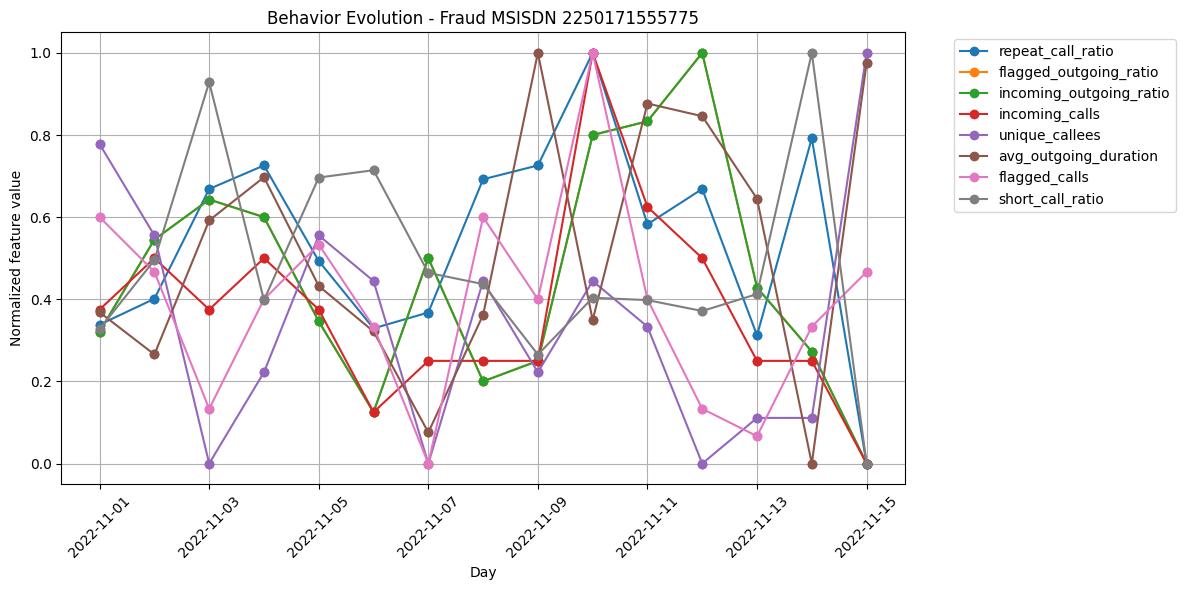

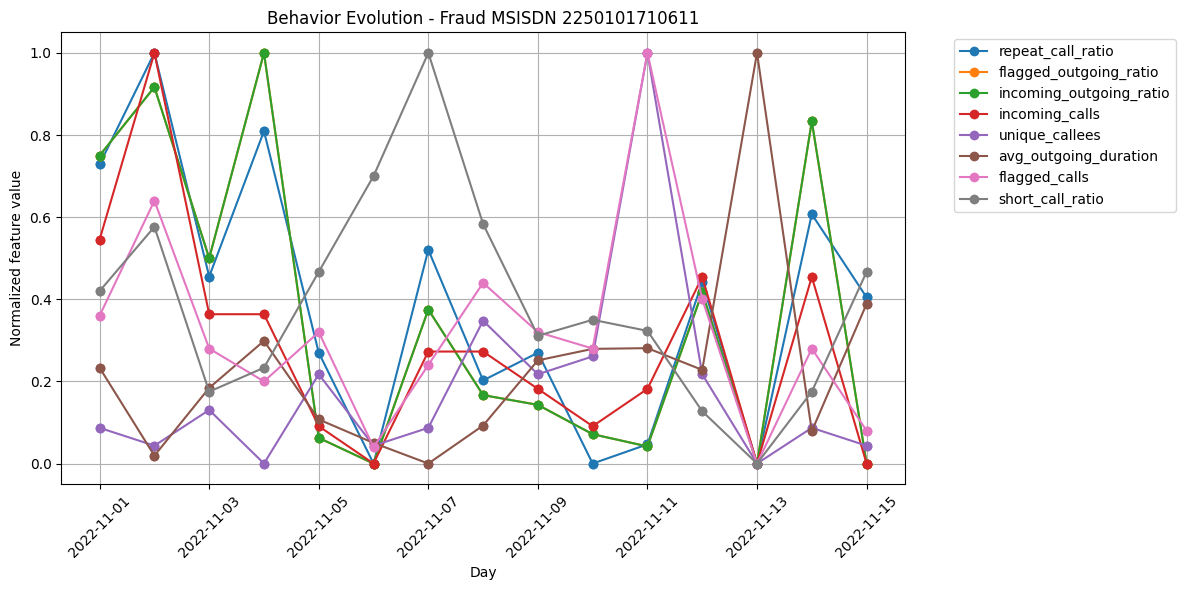

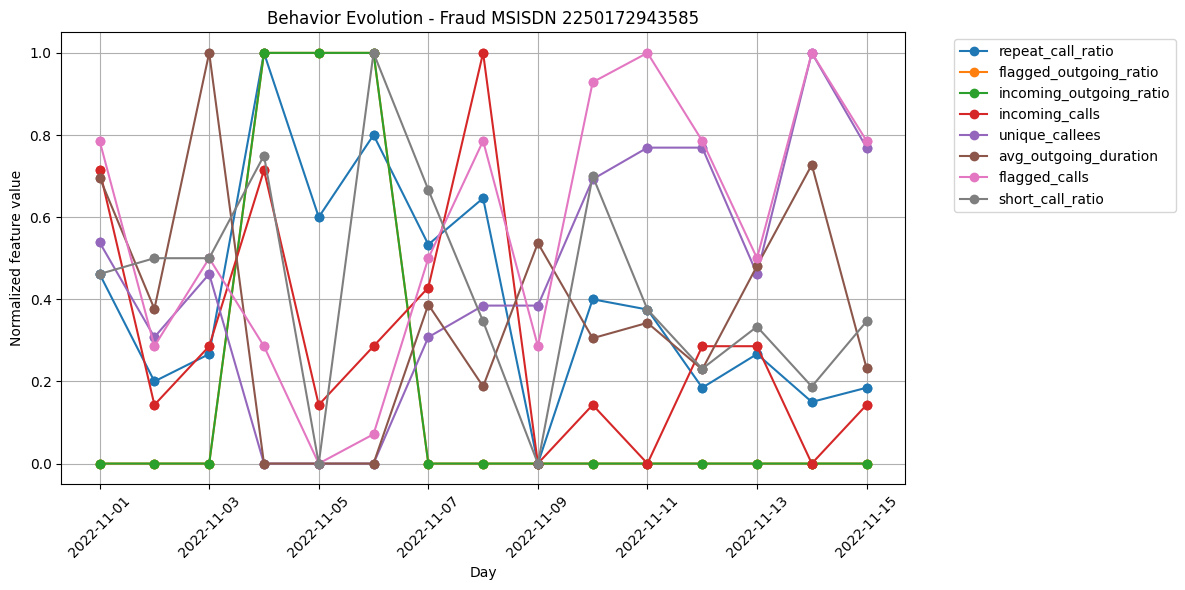

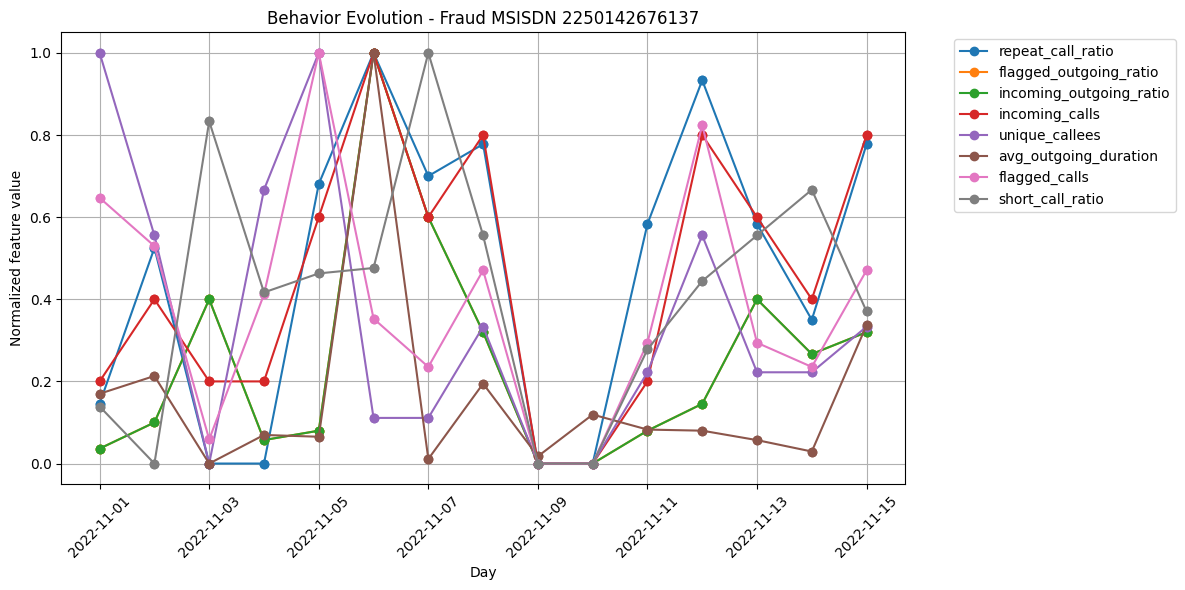

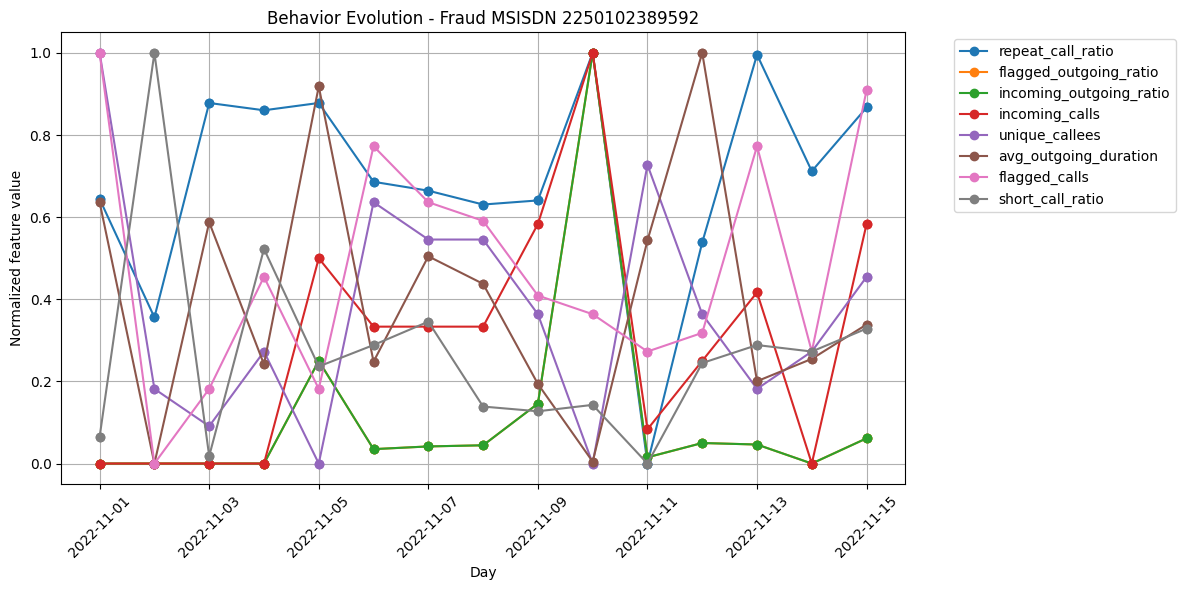

In [4]:
import matplotlib.pyplot as plt

# ============================
# Load profiles
# ============================

profiles_df = pd.read_parquet(PROFILE_PATH)

profiles_df["profile_date"] = pd.to_datetime(
    profiles_df["profile_date"]
)

# ============================
# Select random fraud MSISDNs
# ============================

n_samples = 10

fraud_msisdns = (
    profiles_df[profiles_df["label"] == 1]["msisdn"]
    .drop_duplicates()
    .sample(
        n=n_samples,
        random_state=42
    )
)

fraud_msisdns.tolist()

# Define the features you want to visualize
features_to_plot = [
    "repeat_call_ratio",
    "flagged_outgoing_ratio",
    "incoming_outgoing_ratio",
    "incoming_calls",
    "unique_callees",
    "avg_outgoing_duration",
    "flagged_calls",
    "short_call_ratio"
]

# Plot each subscriber
for msisdn in fraud_msisdns:

    user_df = (
        profiles_df[
            profiles_df["msisdn"] == msisdn
        ]
        .sort_values("profile_date")
        .copy()
    )

    # Normalize features per subscriber
    normalized_df = user_df[features_to_plot].copy()

    normalized_df = (
        normalized_df - normalized_df.min()
    ) / (
        normalized_df.max() - normalized_df.min()
    )

    normalized_df = normalized_df.fillna(0)

    plt.figure(figsize=(12, 6))

    for feature in features_to_plot:
        plt.plot(
            user_df["profile_date"],
            normalized_df[feature],
            marker="o",
            label=feature
        )

    plt.title(
        f"Behavior Evolution - Fraud MSISDN {msisdn}"
    )

    plt.xlabel("Day")
    plt.ylabel("Normalized feature value")

    plt.xticks(
        rotation=45
    )

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.grid(True)
    plt.tight_layout()

    plt.show()